In [2]:
from arraylake import Client
import zarr

ARRAYLAKE_REPO = "GFDL/noaa-gfdl-spear-large-ensembles-pds"
ARRAYLAKE_BRANCH = "main"

client = Client()
repo = client.get_repo(ARRAYLAKE_REPO)
session = repo.readonly_session(branch=ARRAYLAKE_BRANCH)

root = zarr.open_group(
    session.store,
    mode="r",
    zarr_format=3,
)

print(root)

ArraylakeClientError: Error response 403 while requesting URL('https://earthmover-production.us.auth0.com/oauth/token'). <Response [403 Forbidden]>: {"error":"invalid_grant","error_description":"Unknown or invalid refresh token."}

In [ ]:
from arraylake import Client
import zarr

ARRAYLAKE_REPO = "GFDL/noaa-gfdl-spear-large-ensembles-pds"
ARRAYLAKE_BRANCH = "main"

API_KEY = ""

client = Client(token=API_KEY)

repo = client.get_repo(ARRAYLAKE_REPO)

session = repo.readonly_session(
    branch=ARRAYLAKE_BRANCH
)

root = zarr.open_group(
    session.store,
    mode="r",
    zarr_format=3,
)

print(root)

<Group <icechunk.store.IcechunkStore object at 0x000002313D996710>>


In [6]:
print("Top-level groups:")
print(list(root.group_keys()))

print("\nTop-level arrays:")
print(list(root.array_keys()))

Top-level groups:
['historical', 'scenarioSSP5-85']

Top-level arrays:
[]


In [8]:
hist = root["historical"]

print("historical groups:")
print(list(hist.group_keys()))

print("\nhistorical arrays:")
print(list(hist.array_keys()))

historical groups:
['6hr', 'Omon', 'Amon', 'day', 'fx', 'Ofx']

historical arrays:
[]


In [9]:
g = root["historical"]["6hr"]

print("historical/6hr groups:")
print(list(g.group_keys()))

print("\nhistorical/6hr arrays:")
print(list(g.array_keys()))

historical/6hr groups:
[]

historical/6hr arrays:
['lat_bnds', 'time', 'member_id', 'lon_bnds', 'pr', 'experiment_id', 'time_bnds', 'lat', 'lon']


C:\Users\Zappa\AppData\Roaming\Python\Python311\site-packages\zarr\codecs\numcodecs\_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [10]:
ARRAYLAKE_GROUP = "historical/6hr"
ARRAYLAKE_VARIABLE = "pr"
ARRAYLAKE_MEMBER = "r1i1p1f1"

In [15]:
ds = xr.open_zarr(
    session.store,
    group=ARRAYLAKE_GROUP,
    zarr_format=3,
    consolidated=False,
)

ds = ds.sel(member_id="r1i1p1f1")
ds = ds.sel(time=slice("1921-01-01T00:00:00", "1930-12-31T23:00:00"))

C:\Users\Zappa\AppData\Roaming\Python\Python311\site-packages\zarr\codecs\numcodecs\_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [14]:
print(ds["member_id"].values)
print(ds["member_id"].dtype)

['r10i1p1f1' 'r11i1p1f1' 'r12i1p1f1' 'r13i1p1f1' 'r14i1p1f1' 'r15i1p1f1'
 'r16i1p1f1' 'r17i1p1f1' 'r18i1p1f1' 'r19i1p1f1' 'r1i1p1f1' 'r20i1p1f1'
 'r21i1p1f1' 'r22i1p1f1' 'r23i1p1f1' 'r24i1p1f1' 'r25i1p1f1' 'r26i1p1f1'
 'r27i1p1f1' 'r28i1p1f1' 'r29i1p1f1' 'r2i1p1f1' 'r30i1p1f1' 'r3i1p1f1'
 'r4i1p1f1' 'r5i1p1f1' 'r6i1p1f1' 'r7i1p1f1' 'r8i1p1f1' 'r9i1p1f1']
<U9


In [12]:
import xarray as xr

In [19]:
ds = xr.open_zarr(
    session.store,
    group=ARRAYLAKE_GROUP,
    zarr_format=3,
    consolidated=False,
)

print(ds["member_id"].values)

ds = ds.sel(member_id="r1i1p1f1")

ds = ds.sel(
    time=slice(
        "1921-01-01T00:00:00",
        "1930-12-31T23:00:00"
    )
)

ds

C:\Users\Zappa\AppData\Roaming\Python\Python311\site-packages\zarr\codecs\numcodecs\_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


['r10i1p1f1' 'r11i1p1f1' 'r12i1p1f1' 'r13i1p1f1' 'r14i1p1f1' 'r15i1p1f1'
 'r16i1p1f1' 'r17i1p1f1' 'r18i1p1f1' 'r19i1p1f1' 'r1i1p1f1' 'r20i1p1f1'
 'r21i1p1f1' 'r22i1p1f1' 'r23i1p1f1' 'r24i1p1f1' 'r25i1p1f1' 'r26i1p1f1'
 'r27i1p1f1' 'r28i1p1f1' 'r29i1p1f1' 'r2i1p1f1' 'r30i1p1f1' 'r3i1p1f1'
 'r4i1p1f1' 'r5i1p1f1' 'r6i1p1f1' 'r7i1p1f1' 'r8i1p1f1' 'r9i1p1f1']


<xarray.Dataset> Size: 12GB
Dimensions:        (time: 14608, lat: 360, lon: 576, experiment_id: 1, bnds: 2)
Coordinates:
  * time           (time) object 117kB 1921-01-01 03:00:00 ... 1930-12-31 21:...
  * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon            (lon) float64 5kB 0.3125 0.9375 1.562 ... 358.4 359.1 359.7
  * experiment_id  (experiment_id) <U10 40B 'historical'
    lat_bnds       (lat, bnds) float64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    lon_bnds       (lon, bnds) float64 9kB dask.array<chunksize=(576, 2), meta=np.ndarray>
    time_bnds      (time, bnds) object 234kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    member_id      <U9 36B 'r1i1p1f1'
Dimensions without coordinates: bnds
Data variables:
    pr             (time, lat, lon) float32 12GB dask.array<chunksize=(1, 360, 576), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            SPEAR
    branch_method:          Initial conditions for this ensemble member were ...
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                gfdl.climate.model.info@noaa.gov
    ...                     ...
    variable_id:            pr
    variant_label:          r10i1p1f1
    cmor_version:           3.13.0
    parent_experiment_id:   none
    title:                  GFDL-SPEAR-MED output prepared for FLP
    license:                CC0-1.0

In [17]:
print(ds["member_id"].values)

r1i1p1f1


In [20]:
ds = open_arraylake_zarr()
print(ds["pr"])
print(ds["pr"].chunks)
print(ds["pr"].encoding)

NameError: name 'open_arraylake_zarr' is not defined

In [21]:
from arraylake import Client
import xarray as xr


ARRAYLAKE_REPO = "GFDL/noaa-gfdl-spear-large-ensembles-pds"
ARRAYLAKE_BRANCH = "main"
ARRAYLAKE_GROUP = "historical/6hr"
ARRAYLAKE_MEMBER = "r1i1p1f1"

client = Client(token=API_KEY)

repo = client.get_repo(
    ARRAYLAKE_REPO
)

session = repo.readonly_session(
    branch=ARRAYLAKE_BRANCH
)

ds = xr.open_zarr(
    session.store,
    group=ARRAYLAKE_GROUP,
    zarr_format=3,
    consolidated=False,
)

ds = ds.sel(member_id=ARRAYLAKE_MEMBER)

ds = ds.sel(
    time=slice(
        "1921-01-01T00:00:00",
        "1930-12-31T23:00:00"
    )
)

print(ds["pr"])
print("\nCHUNKS:")
print(ds["pr"].chunks)

print("\nENCODING:")
print(ds["pr"].encoding)

C:\Users\Zappa\AppData\Roaming\Python\Python311\site-packages\zarr\codecs\numcodecs\_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.DataArray 'pr' (time: 14608, lat: 360, lon: 576)> Size: 12GB
dask.array<getitem, shape=(14608, 360, 576), dtype=float32, chunksize=(1, 360, 576), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 117kB 1921-01-01 03:00:00 ... 1930-12-31 21:00:00
  * lat        (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon        (lon) float64 5kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
    member_id  <U9 36B 'r1i1p1f1'
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          kg m-2 s-1
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

CHUNKS:
((1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

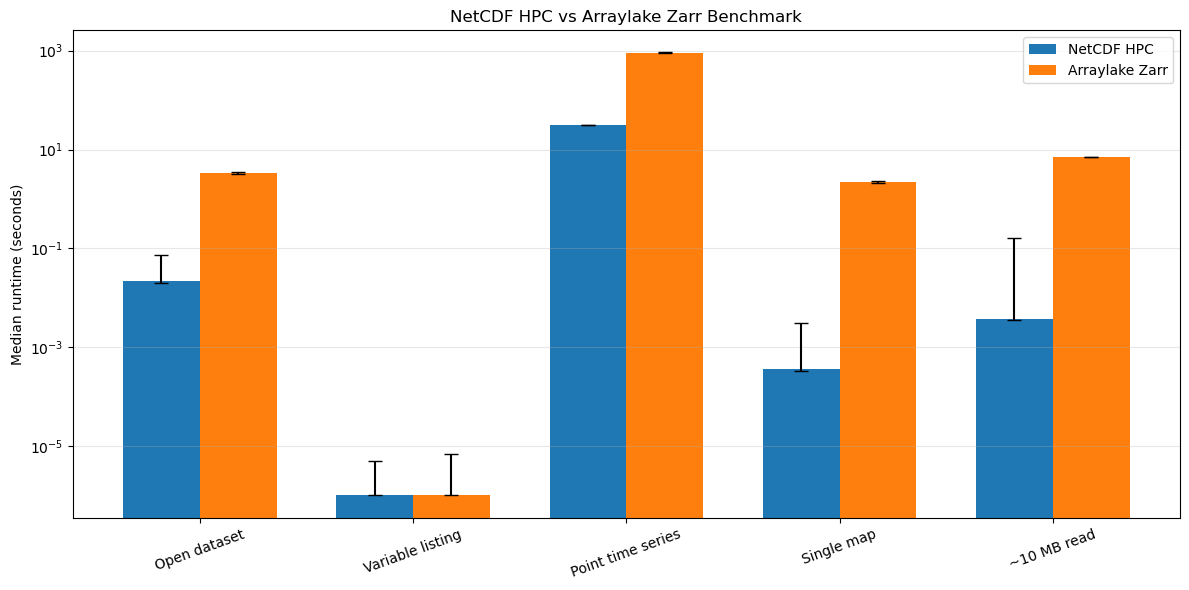

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Benchmark data from stats_nczarr.txt
# ============================================================

tests = [
    "Open dataset",
    "Variable listing",
    "Point time series",
    "Single map",
    "~10 MB read",
]

# ---------------------------
# NetCDF HPC
# ---------------------------

netcdf_median = [
    0.022001,
    0.000001,
    31.300338,
    0.000368,
    0.003761,
]

netcdf_min = [
    0.019732,
    0.000001,
    31.016918,
    0.000332,
    0.003568,
]

netcdf_max = [
    0.073422,
    0.000005,
    31.929027,
    0.003099,
    0.164797,
]

# ---------------------------
# Arraylake Zarr
# ---------------------------

zarr_median = [
    3.422836,
    0.000001,
    909.600458,
    2.169595,
    6.999026,
]

zarr_min = [
    3.239108,
    0.000001,
    904.396317,
    2.069606,
    6.941197,
]

zarr_max = [
    3.514536,
    0.000007,
    920.277565,
    2.256010,
    7.079726,
]

# ============================================================
# Error bars
# ============================================================

netcdf_lower = np.array(netcdf_median) - np.array(netcdf_min)
netcdf_upper = np.array(netcdf_max) - np.array(netcdf_median)

zarr_lower = np.array(zarr_median) - np.array(zarr_min)
zarr_upper = np.array(zarr_max) - np.array(zarr_median)

# ============================================================
# Plot
# ============================================================

x = np.arange(len(tests))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

# NetCDF bars
ax.bar(
    x - width/2,
    netcdf_median,
    width,
    label="NetCDF HPC",
    yerr=[netcdf_lower, netcdf_upper],
    capsize=5,
)

# Zarr bars
ax.bar(
    x + width/2,
    zarr_median,
    width,
    label="Arraylake Zarr",
    yerr=[zarr_lower, zarr_upper],
    capsize=5,
)

# ============================================================
# Formatting
# ============================================================

ax.set_yscale("log")

ax.set_xticks(x)
ax.set_xticklabels(tests, rotation=20)

ax.set_ylabel("Median runtime (seconds)")
ax.set_title("NetCDF HPC vs Arraylake Zarr Benchmark")

ax.legend()

ax.grid(
    axis="y",
    which="both",
    alpha=0.3,
)

plt.tight_layout()
plt.show()